# Working with n-dimensional potentials

In all the other tutorials, the potentials used are 2-dimensional, but `bloch_schrodinger` is also able to work using 1D and 3D potentials, and uses then almost the same syntax. 

In this tutorial, we are going to show how to work with such potentials and how to visualize them. To do so, we are going to work every time with the classic harmonic potential.

## Defining the potentials

To define a nD potential, one uses the same syntax as always, but with nD unit vectors and a length-n resolution tuple.

In [1]:
from bloch_schrodinger.potential import Potential

# Defining some constants
hbar = 1 
m = 1

unitvecs_1D = [[10]]

foo_1D = Potential(
    unitvecs=unitvecs_1D,
    resolution=(1000,),
)

unitvecs_2D = [
    [10, 0], 
    [0, 8]
]


foo_2D = Potential(
    unitvecs=unitvecs_2D,
    resolution=(75,65), # Reduced resolution as each dimension resolution multiplies
)


unitvecs_3D = [
    [10, 0, 0],
    [0, 8, 0],
    [0,0,11],
]

foo_3D = Potential(
    unitvecs=unitvecs_3D,
    resolution=(40, 30, 45),
)

print(foo_1D)
print(foo_2D)
print(foo_3D)

Potential (1D): a1 = [10] 
 dimensions: {'a1': 1000}
Potential (2D): a1 = [10  0], a2 = [0 8] 
 dimensions: {'a1': 75, 'a2': 65}
Potential (3D): a1 = [10  0  0], a2 = [0 8 0], a3 = [ 0  0 11] 
 dimensions: {'a1': 40, 'a2': 30, 'a3': 45}


Now let's initialize the harmonic trap:

In [2]:
Omega = [4,4,3]

def harmonic(*xyz):
    pot = 0
    for i, coo in enumerate(xyz):
        pot = pot + Omega[i]**2 / 2 * coo**2
    return pot

foo_1D.set(harmonic(*foo_1D.coords)) # The coords attribute of a potential contains the cartesian multidimensional 
foo_2D.set(harmonic(*foo_2D.coords)) # coordinates of the potential, in the "x", "y", "z" order
foo_3D.set(harmonic(*foo_3D.coords))

Now that the potentials are set, we can plot them using the `Potential.plot` function, leveraging the `cart_axes` argument which specifies against which cartesian dimension to plot. 

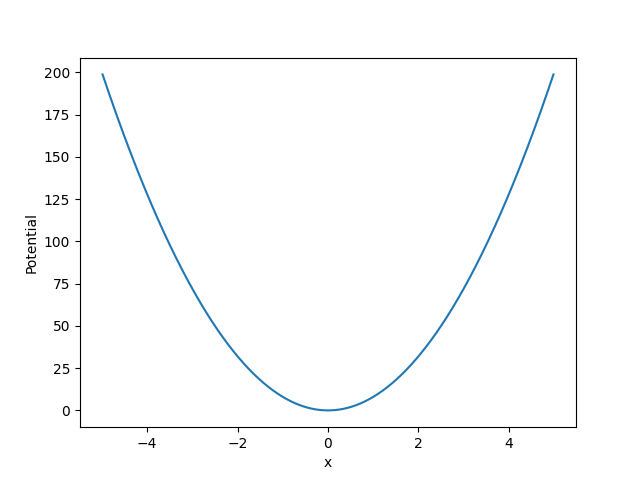

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt

foo_1D.plot(cart_axes=[0])
plt.show()


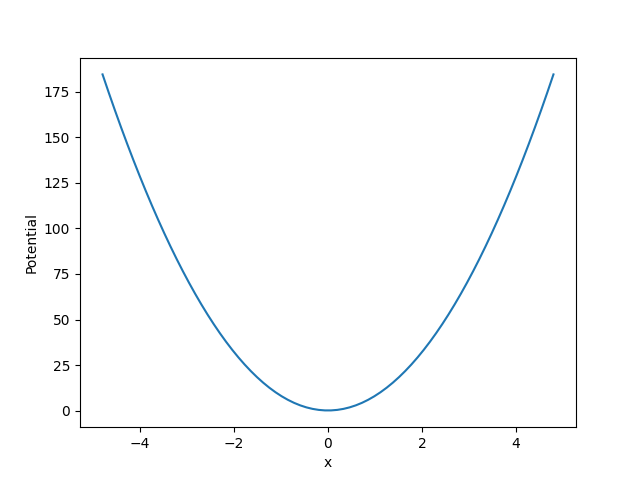

In [4]:

foo_2D.plot(cart_axes=[0])
plt.show()


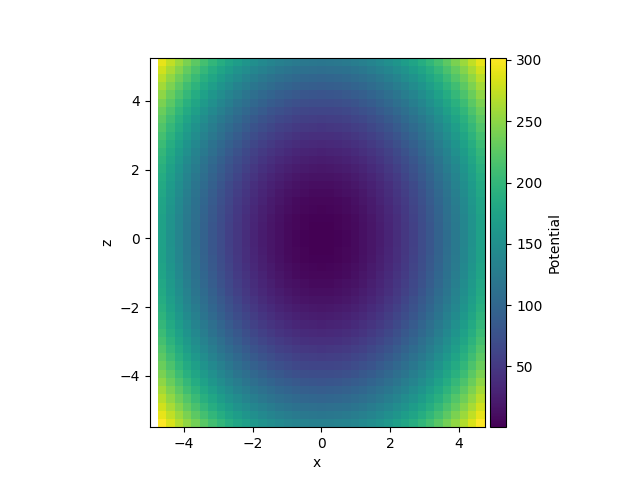

In [5]:

foo_3D.plot(cart_axes=[0,2])
plt.show()

As can be seen in those rather boring plots, the plot function offers the possibility of choosing the cartesian dimension against which to plot. As of now, only 1D and 2D plots are available, and 3D plots are always shown as cuts.

## Finding and plotting the eigenvectors

Now that we have defined the potential, we can use the `FDSolver` just like for 2D potentials. Note that the finite-difference schemes used are different each time, in particular, the second-order anisotropy for 3D potentials are not suppressed fully as in 2D. 

In [6]:
from bloch_schrodinger.fdsolver import FDSolver

bar_1D = FDSolver(foo_1D, hbar**2/2/m)
bar_2D = FDSolver(foo_2D, hbar**2/2/m)
bar_3D = FDSolver(foo_3D, hbar**2/2/m)

n = 3
eigva_1D, eigve_1D = bar_1D.solve(n_eigva = n)
eigva_2D, eigve_2D = bar_2D.solve(n_eigva = n*3)
eigva_3D, eigve_3D = bar_3D.solve(n_eigva = n*6)


Diagonalizing:   0%|          | 0/1 [00:00<?, ?matrix/s]

Diagonalizing:   0%|          | 0/1 [00:00<?, ?matrix/s]

Diagonalizing:   0%|          | 0/1 [00:00<?, ?matrix/s]

Now we can plot the results using the `plot_eigenvector` function and the same `cart_axes` logic

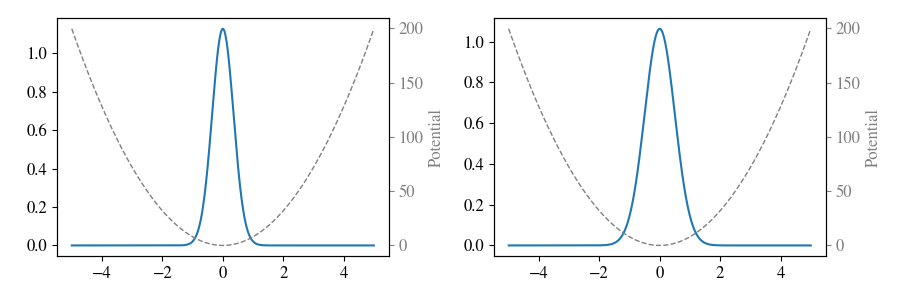

In [7]:
from bloch_schrodinger.plotting import plot_eigenvector
import numpy as np

plot_eigenvector(
    [[np.abs(eigve_1D)**2, eigve_1D.real]],
    potentials=[[foo_1D]*2],
    cart_axes=[0]
)
plt.show()

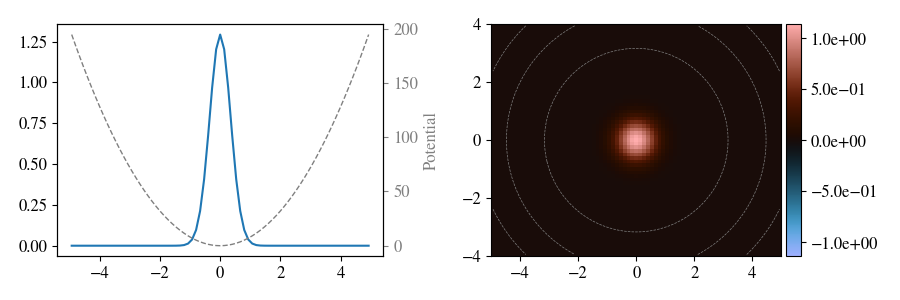

In [8]:
plot_eigenvector(
    [[np.abs(eigve_2D)**2, eigve_2D.real]],
    potentials=[[foo_2D]*2],
    templates=[[None, "real"]],
    cart_axes=[[[0], [0,1]]]
)
plt.show()

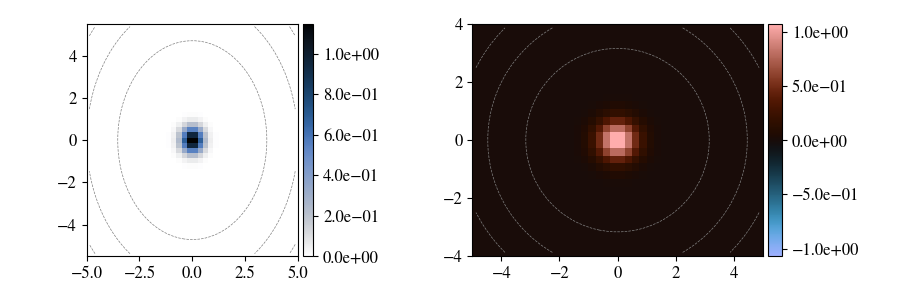

In [9]:
plot_eigenvector(
    [[np.abs(eigve_3D)**2, eigve_3D.real]],
    potentials=[[foo_3D]*2],
    cart_axes=[[[0,2], [0,1]]],
    templates=[["amplitude", "real"]],

)
plt.show()

For 3D potentials, a dedicated plotting function exists: `plot_isosurface`. Unlike the matplotlib-based functions above, it renders with plotly.

It draws the mode as a surface in space, and it takes *two* independent fields: `volume` sets the shape of the surface, while `color` is painted onto it. For a complex eigenvector the natural pair is the modulus and the phase.


The `isovalue` slider sets which level the surface follows, as a fraction of the selected mode's own range, so a surface stays visible when switching between modes of very different amplitudes. If a `potential` is given, one of its equipotentials is drawn as a translucent shell for context, with its own `V level` slider.

In [10]:
from bloch_schrodinger.plotting import plot_isosurface
import xarray as xr

plot_isosurface(
    np.abs(eigve_3D),                 # the modulus shapes the surface
    color=xr.ufuncs.angle(eigve_3D),  # the phase is painted onto it
    potential=foo_3D,
    isovalue=0.3,
    colorscale="twilight",
    cyclic=True,                      # the phase wraps at +/- pi, so interpolate it the short way round
)

FigureWidget({
    'data': [{'flatshading': False,
              'i': {'bdata': ('AgAAAAQAAAAAAAAABAAAAAEAAAAAAA' ... 'AAAMkAAADYAAAAzgAAANEAAADRAAAA'),
                    'dtype': 'i4'},
              'j': {'bdata': ('AQAAAAMAAAADAAAABQAAAAYAAAAGAA' ... 'AAANkAAADOAAAA2AAAANgAAADZAAAA'),
                    'dtype': 'i4'},
              'k': {'bdata': ('AAAAAAAAAAACAAAAAwAAAAAAAAAEAA' ... 'AAAMgAAADGAAAA0QAAANkAAADJAAAA'),
                    'dtype': 'i4'},
              'lighting': {'ambient': 0.55, 'diffuse': 0.8, 'roughness': 0.5, 'specular': 0.2},
              'name': 'mode',
              'type': 'mesh3d',
              'uid': 'ae0c809f-9f31-4e3e-bfcc-3dc3d693d46a',
              'vertexcolor': {'bdata': ('LxM3LxM3LxM3LxM3LxM3LxM3LxM3Lx' ... 'Q2LxQ2LxQ2LxQ2LxQ2LxQ2LxQ2LxQ2'),
                              'dtype': 'u1',
                              'shape': '218, 3'},
              'x': {'bdata': ('MGZmhrXa6L8wZmZmZmbnvzBmZmZmZu' ... 'aSieA/sGZmhrXa6D+wZmaGtdroPw=='),
       